In this notebook, we continue with the analysis of implied volatility index: VIX.

Workflow:
1. Model the differences of log-vix data
2. Kalman filter
- definition of the state space
- state space model
- RLS algorithm with adaptive Q and R
3. non-linear filters
- UKF
- attempt for adaptive Q and R





In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

We are going to model the log-differences of VIX values, let $v_t = \log (vix_t)$:
$$y_t = \Delta v_t= v_t - v_{t-1}, \quad vix_t = \exp(v_t) = \exp(v_{t-1} + \Delta v_t) = \exp(v_{t-1} + y_t)$$

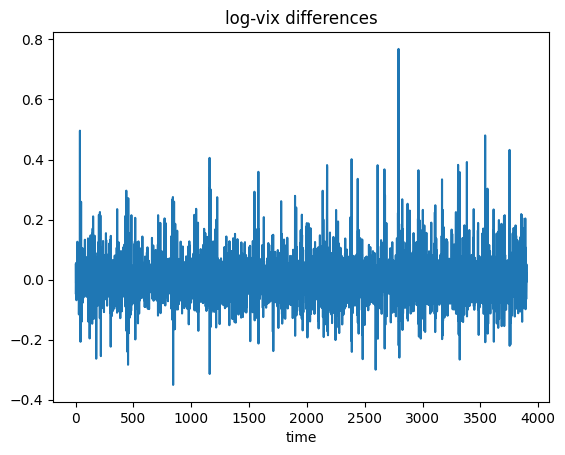

In [3]:
df_full = pd.read_csv('/content/drive/MyDrive/spx_vol.csv')
vix = df_full['vix'].dropna()
log_vix = np.log(vix)
y = log_vix.diff()
plt.plot(y)
plt.xlabel("time")
plt.title("log-vix differences")
plt.show()

# Kalman filter

## State space
$$y_t = x_t^T\beta_t + e_t, \quad e_t \sim \mathcal{N}(0, R)$$
random walk in parameters
$$\beta_t = \beta_{t-1} + ϵ_t, \quad ϵ_t \sim \mathcal{N}(0, Q)$$
We have $\beta_{t-1|y_1,\dots, y_{t-1}} \sim \mathcal{N}(\hat{\beta}_{t-1}, P_{t-1})$. The moments are
$$E[\beta_t|y_{1, \dots, t-1}] = \hat{\beta}_t, \quad Var[\beta_t|y_{1,\dots,t-1}] = P_{t-1} + Q,$$with the estimated covariance
$$S_t =  x_t^TP_{t-1}^{+}x_t + R.$$


$$\begin{pmatrix}\beta_t \\ y_t\end{pmatrix} \sim \mathcal{N}\left(\begin{pmatrix}\hat{\beta}_t\\x_t^T\hat{\beta}_t\end{pmatrix}, \begin{pmatrix}P_{t-1}^{+} & P_{t-1}^{+}x_t \\ x_t^TP_{t-1}^{+} & S_t\end{pmatrix}\right)$$
And the update equations for our Kalman filter are
$$K_t = P_{t-1}^{+}x_tS_t^{-1}, \quad P_t = (I - Kx_t^T)P_{t-1}^{+}.$$

The covariances R and Q are updated as an exponential moving average, where we adjust the previous variance by the one observed in this step.
$$\hat{R}_t = (1-\alpha_1)\hat{R}_{t-1} + \alpha_1 v_tv_t^T, \quad v_t = y_t - \hat{y}_t$$
$$\hat{Q}_t = (1-\alpha_2)v_t^TK^TKv_t + \alpha_2Kx_t^TP_{t-1}^{+},$$
where $\alpha_1 = 0.01, \alpha_2 = 0.1$ because we assume the parameter $\beta$ won't change that frequently.
- This is just my idea I am not sure, whether this is actually done in practise. It has little effect on the filtering.

In [20]:
def kalman_tv_regression(y, X, Q_diag=1e-6, R=1e-4, P0_scale=100.0, beta0=None):
    """
    Kalman filter for time-varying linear regression (random-walk state).
    :arg
      y        : array-like shape (T,)
      X        : array-like shape (T, m), regressors
      Q_diag   : scalar or array (m,), process noise
      R        : scalar, observation noise variance
      P0_scale : scalar, initial covariance P0 = P0_scale * I
      beta0    : array-like (m,), initial state

    :returns
      dict with keys:
        'beta_filtered'  : (T, m) filtered state estimates
        'y_pred'         : (T,) one-step-ahead predictions
        'innov'          : (T,) innovations v_t = y_t - y_pred
        'S'              : (T,) innovation variances
        'P'              : (T, m, m) posterior covariances (optional large mem)
        'loglik'         : log-likelihood
    """
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    T, m = X.shape
    if beta0 is None:
        beta = np.zeros(m)
    else:
        beta = np.asarray(beta0, dtype=float).copy()

    P = np.eye(m) * P0_scale
    if np.isscalar(Q_diag):
        Q = np.eye(m) * Q_diag
    else:
        Q = np.diag(np.asarray(Q_diag, dtype=float))

    R = float(R)
    alpha1 = 0.01
    alpha2 = 0.1

    beta_hist = np.zeros((T, m))
    y_pred = np.zeros(T)
    innov = np.zeros(T)
    S_arr = np.zeros(T)
    P_hist = np.zeros((T, m, m))

    loglik = 0.0
    for t in range(T):
        xt = X[t][:, None]
        # get new parameters
        beta_pred = beta
        P_pred = P + Q

        # make prediction
        yhat = float(xt.T @ beta_pred)
        y_pred[t] = yhat
        vt = y[t] - yhat

        # update
        R = (1 - alpha1) * R + alpha1 * (vt**2)
        if R < 0.00001:
            R = 0.00001

        S = float(xt.T @ P_pred @ xt) + R
        K = (P_pred @ xt) / S

        beta = beta_pred + (K.flatten() * vt)
        P = P_pred - (K @ (xt.T @ P_pred))

        diff_beta = K.flatten() * vt
        diff_P = K @ (xt.T @ P_pred)

        Q_hat = np.diag((1-alpha2)*np.outer(diff_beta, diff_beta) + alpha2*(diff_P))
        Q = np.diag(Q_hat)


        # save data
        beta_hist[t, :] = beta
        innov[t] = vt
        S_arr[t] = S
        P_hist[t, :, :] = P

        loglik += -0.5 * (np.log(2*np.pi) + np.log(S) + (vt**2) / S)

    return {
        'beta_filtered': beta_hist,
        'y_pred': y_pred,
        'innov': innov,
        'S': S_arr,
        'P': P_hist,
        'loglik': loglik
    }


We will use the same regressor $x_t$, that was estimated previously as the best: ARMA(2,1)

In [21]:
v = log_vix.reindex(y.index)
window_ma = 5

X_df = pd.DataFrame(index=y.index)
X_df['const'] = 1.0
X_df['vix_lag1'] = v.shift(1)
X_df['vix_lag2'] = v.shift(2)
X_df['vix_ma'] = v.rolling(window=window_ma).mean()

combined = pd.concat([y.rename('y'), X_df], axis=1).dropna()
y_clean = combined['y'].values
X_clean = combined[['vix_lag1','vix_lag2','vix_ma']].values

The MSE of our Kalman filter is compared to the MSE from naive forecast (same volatility as previous day: $\hat{\Delta \log VIX} = \hat{y} = 0$)

<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-980155890.py:27: SyntaxWarning: invalid escape sequence '\D'
  plt.title(f"residuals vs. $\Delta \log VIX$")
/tmp/ipython-input-3460274162.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yhat = float(xt.T @ beta_pred)
/tmp/ipython-input-3460274162.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  S = float(xt.T @ P_pred @ xt) + R


|-------------||-------------|
MSE: 0.005213881843251231
MSE naive:  0.006128655857592696
R2:  0.14926176890943643
Log-lik: 4782.798401362028


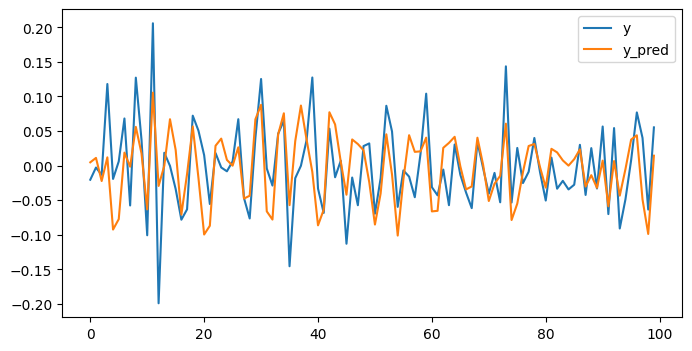

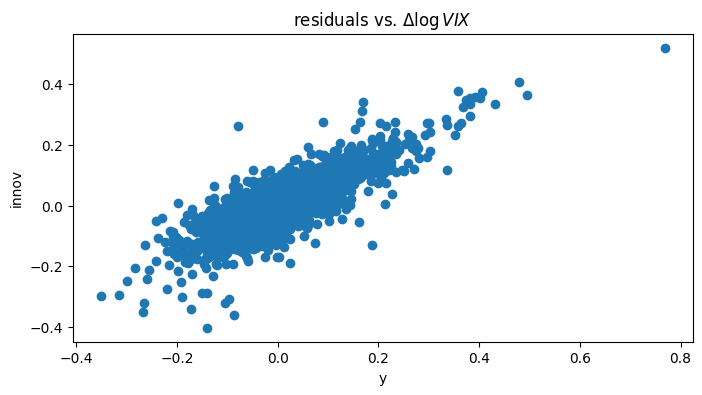

In [24]:
res_kf = kalman_tv_regression(y_clean, X_clean,
                              Q_diag=1e-3, R=1e-4, P0_scale=1.0)

beta_t = res_kf['beta_filtered']
y_pred = res_kf['y_pred']
innov = res_kf['innov']

ss_res = np.sum(innov**2)
ss_tot = 0
for i in range(1, len(y_clean)):
  ss_tot += y_clean[i]**2
r2 = 1 - ss_res / ss_tot
print("|-------------||-------------|")
print("MSE:", ss_res/len(y_clean))
print("MSE naive: ", ss_tot/len(y_clean))
print("R2: ", r2)
print("Log-lik:", res_kf['loglik'])

plt.figure(figsize=(8, 4))
plt.plot(y_clean[500:600], label='y')
plt.plot(y_pred[500:600], label='y_pred')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(y_clean, innov)
plt.title(f"residuals vs. $\Delta \log VIX$")
plt.xlabel("y")
plt.ylabel("innov")
plt.show()



The res vs. $\Delta \log VIX$ plot shows that our model likely predicts zeros or near zero values most of the time. Yet the $R^2$ for our Kalman filter is about 0.15.

We recover the predictions for VIX values (day-by-day, using the observed previous VIX values + predicted differences of log-VIX). Then we recompute the $R^2$, which is computed with comparison to MSE given by the naive forecast (now with VIX values).

The VIX array has to be shifted by 5 due to the regressor $x$ in Kalman filter using MA(5).

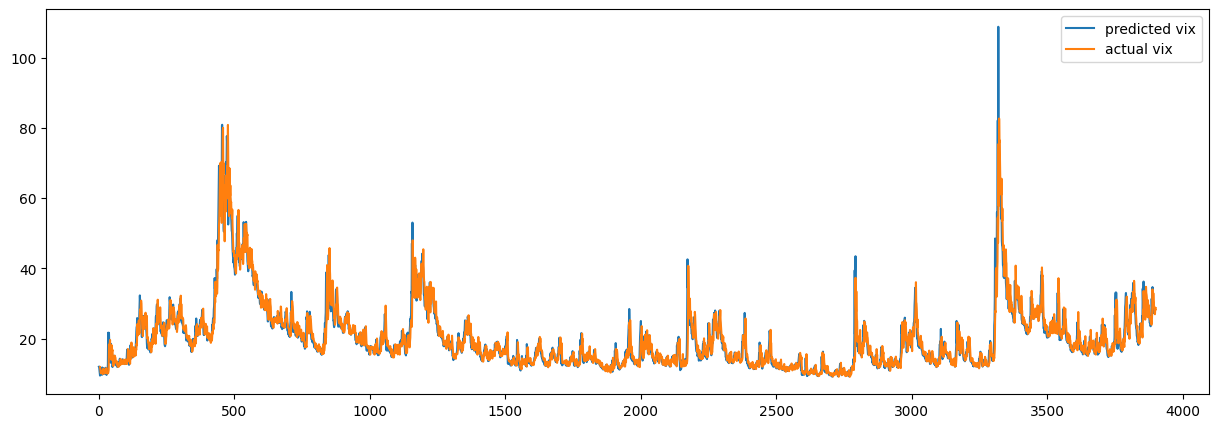

MSE naive:  4.21140066522456
MSE: 4.000114628006618
R2: 0.05017001563461443


In [25]:
v_vals = []
for i in range(len(y_pred)):
  v_vals.append(log_vix[i+3] + y_pred[i]) # at time step i, we already have access to log_vix data from the previous day

v_vals_arr = np.array(v_vals)
pred_vix = np.exp(v_vals_arr)

plt.figure(figsize=(15,5))
ax = plt.gca()
ax.plot(pred_vix, label="predicted vix")
ax.plot(vix[4:], label="actual vix")
plt.legend()
plt.show()

mse_vix = np.mean((pred_vix - vix[4:])**2)
ss_vix = 0
vix_4 = vix[4:].values
for i in range(1, len(vix[4:])):
  ss_vix += (vix_4[i-1] - vix_4[i])**2
ss_vix /= len(vix_4)
r2_vix = 1 - mse_vix / ss_vix
print("MSE naive: ", ss_vix)
print("MSE:", mse_vix)
print("R2:", 1 - mse_vix/ss_vix)


## UKF
unscented Kalman filter uses non-linear equations for the state evolution.
$$y_t = h(x_t) + e_t, \quad \mathcal{N}(0, R),$$

$$x_t = f(x_{t-1}) + w_t, \quad \mathcal{N}(0, Q).$$

The UKF takes the current mean and covariance for the state, $\bar{x}_{t-1}, P_{t-1}$, samples **sigma points** $x_i$ and transforms them with functions $f, h$ to obtain the actual mean, variance estimate.

1.   Sample **sigma points**, $x_i \sim \mathcal{N}(\bar{x}, P)$

*   Compute predicted $\bar{x}^{+}, P_{t-1}^{+}$ from these sigma points

2.   Get the state points, $x_i^{\ast} = f(x_i)$
3.   Get the predictions, $y_i = h(x_i^{\ast})$

*   Compute the predicted $y_t = \frac{1}{n} \sum_i(y_i)$

The algorithm used here is presented in article: https://groups.seas.harvard.edu/courses/cs281/papers/unscented.pdf

In [31]:
import numpy as np
from scipy.linalg import cholesky

class UKF:
    def __init__(self, dim_x, dim_y, f, h, x0, P0, Q, R, alpha_r=0.5*1e-2, alpha_q=1e-3, alpha=1e-2, beta=3., kappa=0.):
        """
        :arg
            dim_x (int): State dimension.
            dim_y (int): Measurement dimension.
            f (callable): State transition function (f(x, dt)).
            h (callable): Measurement function (h(x)).
            x0 (np.array): Initial state estimate.
            P0 (np.array): Initial state covariance.
            Q (np.array): Process noise covariance.
            R (np.array): Measurement noise covariance.
            alpha (float): UKF tuning parameter (spread of sigma points).
            beta (float): UKF tuning parameter (incorporates prior knowledge).
            kappa (float): UKF tuning parameter.
        """
        self.dim_x = dim_x
        self.dim_y = dim_y
        self.f = f
        self.h = h

        # State and Covariance
        self.x = x0.copy()
        self.P = P0.copy()

        # Noise Covariances
        self.Q = Q.copy()
        self.R = R.copy()

        # Adaptation Parameters
        self.alpha_q = alpha_q
        self.alpha_r = alpha_r

        # Sigma Points
        self.n = dim_x
        self.n_sigma = 2 * self.n + 1

        # params
        self.alpha = alpha
        self.beta = beta
        self.kappa = kappa

        self.lambda_ = self.alpha**2 * (self.n + self.kappa) - self.n

        # Calculate Sigma Point Weights
        self.W_m = np.full(self.n_sigma, 1 / (2 * (self.n + self.lambda_)))
        self.W_c = np.full(self.n_sigma, 1 / (2 * (self.n + self.lambda_)))

        # Weights for the 0th sigma point
        self.W_m[0] = self.lambda_ / (self.n + self.lambda_)
        self.W_c[0] = (self.lambda_ / (self.n + self.lambda_)) + (1 - self.alpha**2 + self.beta)

        self.X_sigma_pred = np.zeros((self.n_sigma, self.n))

    def _generate_sigma_points(self):
        """
        Generates sigma points based on the current state and covariance x, P.
        """
        sigma_points = np.zeros((self.n_sigma, self.n))

        try:
            L = cholesky((self.n + self.lambda_) * self.P)
        except np.linalg.LinAlgError:
            L = cholesky((self.n + self.lambda_) * self.P + 1e-6 * np.eye(self.n))

        sigma_points[0] = self.x

        for i in range(self.n):
            sigma_points[i + 1] = self.x + L[i]
            sigma_points[i + 1 + self.n] = self.x - L[i]

        return sigma_points

    def predict(self, dt=1.0, **f_kwargs):
        """
        Performs the predict step of the UKF.
        """
        # 1. Generate sigma points
        X_sigma = self._generate_sigma_points()

        # 2. Get the predicted next state
        for i in range(self.n_sigma):
            self.X_sigma_pred[i] = self.f(X_sigma[i], dt, **f_kwargs)

        # 3. Calculate predicted mean
        self.x = np.dot(self.W_m, self.X_sigma_pred)

        # 4. Calculate predicted covariance
        self.P = np.zeros((self.n, self.n))
        for i in range(self.n_sigma):
            diff = self.X_sigma_pred[i] - self.x
            self.P += self.W_c[i] * np.outer(diff, diff)

        # Add process noise
        self.P += self.Q

    def update(self, y, **h_kwargs):
        """
        Performs the update step of the UKF.
        """
        # 1. Get the predicted y
        Y_sigma_pred = np.zeros((self.n_sigma, self.dim_y))
        for i in range(self.n_sigma):
            Y_sigma_pred[i] = self.h(self.X_sigma_pred[i], **h_kwargs)

        # 2. Calculate predicted (weighted) y mean
        y_pred = np.dot(self.W_m, Y_sigma_pred)

        # 3. Calculate cross-covariance P_xy and innovation covariance S
        S = np.zeros((self.dim_y, self.dim_y))
        P_xy = np.zeros((self.n, self.dim_y))

        for i in range(self.n_sigma):
            diff_x = self.X_sigma_pred[i] - self.x
            diff_y = Y_sigma_pred[i] - y_pred

            S += self.W_c[i] * np.outer(diff_y, diff_y)
            P_xy += self.W_c[i] * np.outer(diff_x, diff_y)

        S_total = S + self.R

        # 4. Calculate Kalman gain K
        K = np.dot(P_xy, np.linalg.inv(S_total))

        # 5. Update state
        v = y - y_pred
        self.x = self.x + np.dot(K, v)

        # 6. Update covariance
        self.P = self.P - np.dot(K, np.dot(S_total, K.T))

        # 7. Adaptively update covariances R an Q
        res_sq = np.outer(v, v)
        self.R = (1-self.alpha_r)*self.R + self.alpha_r * (res_sq - S_total)/S
        self.R = np.maximum(self.R, 0.5 * np.eye(self.dim_y))

        dx = np.dot(K, v)
        dx_sq = np.outer(dx, dx)

        self.Q = (1 - self.alpha_q)*self.Q + self.alpha_q * dx_sq
        self.Q = np.maximum(self.Q, 1e-3 * np.eye(self.dim_x))



## Evolution equations

The state has a linar evolution

$$x_t = f(x_{t-1)}) = \mu + \phi(x_{t-1} - \mu) + w_t$$

$$y_t = h(x_t) = \exp(x_{t}) + e_t$$

parameters


*   $\mu$ - mean in the mean reversion equation (let's say $\mu = \log(20)$)
*   $\phi$ - speed of the mean reversion, close to 1: reversion takes a long time (chosen: $\phi = 0.99$)
*   Q - initial process variance, before we chose $Q = 0.001$
*   R - initial measurement variance, before we chose $R = 0.0001$ (probably should be higher, so here we took: $R = 0.5$)



We are going to also use adaptive $Q$ and $R$, $\alpha_r=0.005$, $\alpha_q = 0.001$. The idea is similar to the adaptive guesses in our Kalman filter.

$$\hat{R} = (1-\alpha_r)R + \alpha_r * \frac{(v^Tv - S_{total})}{S},$$

$$\hat{Q} = (1 - \alpha_q)Q + \alpha_q Kv$$

I am again unsure about the correctness of my implementation. This was my simple attempt for adaptive covariance estimates.

where $S =\sum_i W_i (y_i-y_{pred})^T (y_i-y_{pred})$,

$S_{total} = S + R$

$K =  P_{xy}S_{total}^{-1}$

The MSE is higher when constant values for $Q$ and $R$ are taken as constant.

Using Parameters: mu=2.9957, phi=0.9900
Using Noise: Q=0.001000, R=0.500000


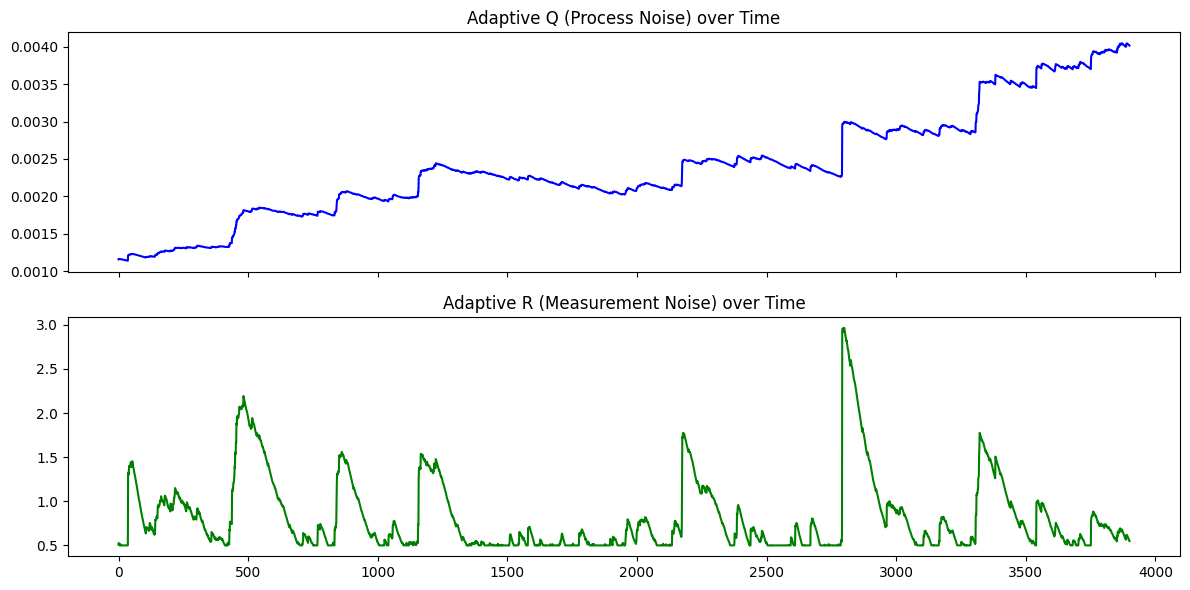

In [32]:
def f_state_vix(x, dt, mu, phi):
    """
    State transition: Mean-reverting AR(1) process on log-volatility (x[0]).
    x_t = mu + phi * (x_t-1 - mu)
    """
    # x is a 1D array [log_vix]
    x_new = mu + phi * (x[0] - mu)
    return np.array([x_new])

def h_measurement_vix(x):
    """
    Measurement function: We observe the VIX, which is exp(log-volatility).
    y = exp(x[0])
    """
    # x is a 1D array [log_vix]
    return np.array([np.exp(x[0])])


# --- 2. Main Execution ---
if __name__ == "__main__":

    param_mu = np.log(20)
    param_phi = 0.99

    Q_val = 1e-3
    R_val = 0.5

    print(f"Using Parameters: mu={param_mu:.4f}, phi={param_phi:.4f}")
    print(f"Using Noise: Q={Q_val:.6f}, R={R_val:.6f}")

    Q_init = np.array([[Q_val]])
    R_init = np.array([[R_val]])

    x0 = np.array([param_mu])
    P0_val = Q_val / (1 - param_phi**2) if (1 - param_phi**2) > 1e-6 else 1.0
    P0 = np.array([[P0_val]])

    ukf = UKF(dim_x=1, dim_y=1,
              f=f_state_vix,
              h=h_measurement_vix,
              x0=x0, P0=P0, Q=Q_init, R=R_init)

    # --- 2e. Run the Filter ---
    filtered_states_log_vix = []
    predicted_states_log_vix = []
    res = []
    Q_history = []
    R_history = []

    for y_obs in vix:
        # Pass your pre-defined model params to the state function
        ukf.predict(dt=1.0, mu=param_mu, phi=param_phi)
        predicted_states_log_vix.append(ukf.x.copy())

        # Update with the measurement (as a 1D array)
        ukf.update(np.array([y_obs]))

        # Store the filtered state
        filtered_states_log_vix.append(ukf.x.copy())
        Y_sigma_pred = np.zeros((ukf.n_sigma, ukf.dim_y))
        for i in range(ukf.n_sigma):
            Y_sigma_pred[i] = ukf.h(ukf.X_sigma_pred[i])
        y_pred = np.dot(ukf.W_m, Y_sigma_pred) # This is your predicted VIX_t|t-1
        Q_history.append(ukf.Q[0,0])
        R_history.append(ukf.R[0,0])

        # Now you can get the residual:
        res.append(y_obs - y_pred[0])



    # Convert state (log-vix) back to VIX level for plotting
    filtered_states_vix = np.exp(np.array(filtered_states_log_vix).squeeze())
    predicted_states_vix = np.exp(np.array(predicted_states_log_vix).squeeze())
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    ax[0].plot(Q_history, 'b-')
    ax[0].set_title("Adaptive Q (Process Noise) over Time")

    ax[1].plot(R_history, 'g-')
    ax[1].set_title("Adaptive R (Measurement Noise) over Time")

    plt.tight_layout()
    plt.show()



We can see that the adaptive R recognizes the schocks in VIX values and reverts back to its initial value but the estimate for Q just keeps rising. This is also influenced by initial settings of $Q, R, \alpha_q, \alpha_q, \phi$. I gave some time to manually tune these parameters but was unable to beat the MSE of the naive prediciton.

The next logical step would be to divide the dataset into training and validation sets, optimize for Q, R and use these as constants in validation. I wanted to make fully online algorithm but this might be a better approach.

In [30]:
mse = np.mean(np.array(res)**2)
mse_naive = np.mean(vix.diff()**2)
print("MSE:", mse)
print("MSE naive: ", mse_naive)

MSE: 4.369243411311788
MSE naive:  4.208342023687211


MSE for the non-adaptive case: 4.369...

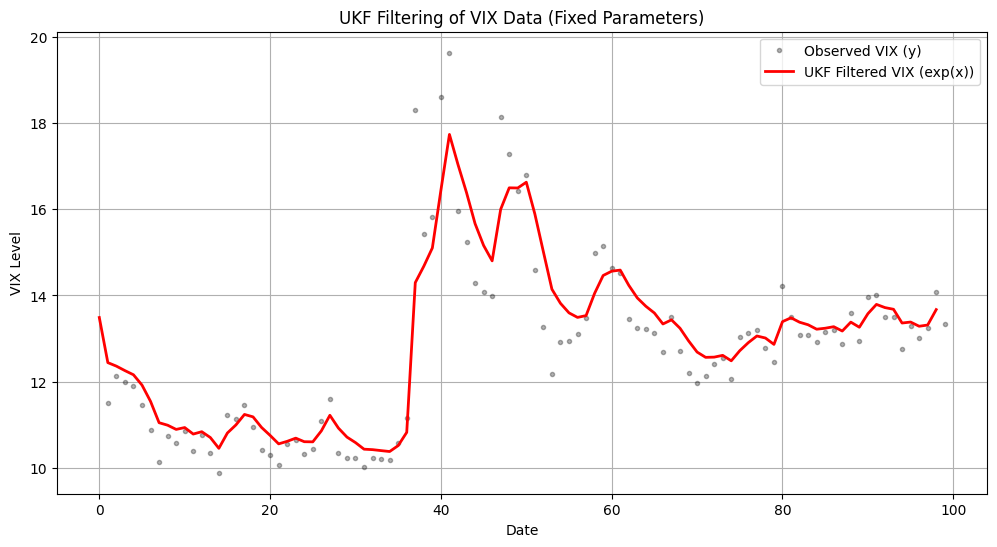

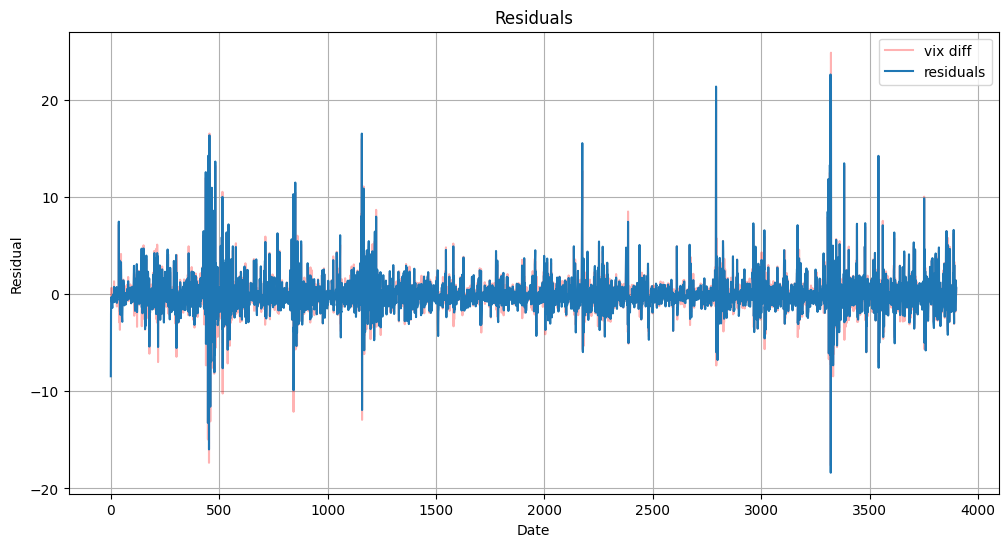

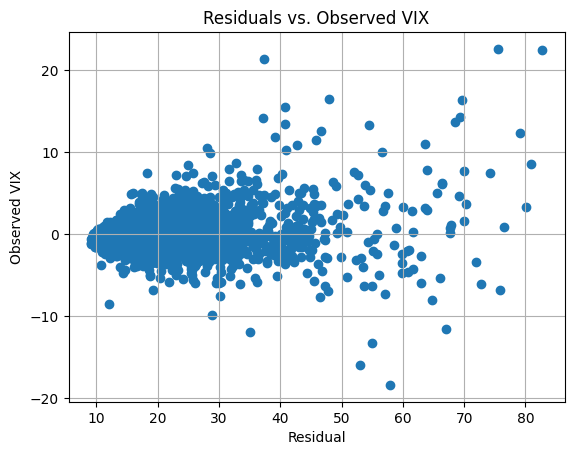

In [33]:
# --- 2f. Plot the Results ---
plt.figure(figsize=(12, 6))
plt.plot(vix[1:100], 'k.', alpha=0.3, label='Observed VIX (y)')
plt.plot(predicted_states_vix[1:100], 'r-', linewidth=2, label='UKF Filtered VIX (exp(x))')
plt.title('UKF Filtering of VIX Data (Fixed Parameters)')
plt.xlabel('Date')
plt.ylabel('VIX Level')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(vix.diff(), color='red', alpha = 0.3, label='vix diff')
plt.plot(res, label='residuals')
plt.title('Residuals')
plt.xlabel('Date')
plt.ylabel('Residual')
plt.grid(True)
plt.legend()
plt.show()

plt.scatter(vix, res)
plt.title('Residuals vs. Observed VIX')
plt.xlabel('Residual')
plt.ylabel('Observed VIX')
plt.grid(True)
plt.show()

The residuals plot shows more significant heteroskedasticity than I would expect.

## Conclusions
In summary, I have implemented a simple Kalman filter with attempt on adaptive estimation of $Q, R$ as well as an UKF for $VIX$ data with linear state evolution and exponential relationship $y = h(x) = \exp(x)$.

Possible next steps:
1. Optimize $Q,R$ on a training dataset and use these values for filtering.
2. Deal with the heteroskedasticity in UKF
3. Bagging - simple RNN that predicts mixing parameter $\varphi$ for our two models: $\hat{y} = \varphi * y^{pred}_{UFK} + (1-\varphi) * y^{pred}_{Kalman}$
